# Wine Quality Dataset - Práctica de Preprocesamiento

El Wine Quality Dataset presenta:
- Pocos datos faltantes (~0.1%)
- Principalmente variables numéricas
- Outliers manejables
- Dominio familiar (vino)
- Tamaño moderado de datos

In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Manejo de advertencias
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
plt.style.use('default')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga y Exploración Inicial

**Objetivo:** Entender la estructura básica del dataset

In [4]:
# Cargar datasets de vino
print("Cargando datasets de wine quality...")
print("="*50)

# Cargar vino rojo y blanco (son dos archivos separados)
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

# Mostrar dimensiones de los datasets
print(f"Wine Red shape: {df_red.shape}")
print(f"Wine White shape: {df_white.shape}")

# Información básica de los datasets: columnas, tipos de datos, valores nulos y primeras filas
print("\nInformación de Wine Red:")
print(df_red.info())
print("\nInformación de Wine White:")
print(df_white.info())
print(f"\nWine White columns: {list(df_white.columns)}")
print(f"\nPrimeras 3 filas de wine white:")
print(df_white.head(3))
print(f"\nWine Red columns: {list(df_red.columns)}")
print(f"\nPrimeras 3 filas de wine red:")
print(df_red.head(3))

Cargando datasets de wine quality...
Wine Red shape: (1599, 12)
Wine White shape: (4898, 12)

Información de Wine Red:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

I

In [5]:
# Combinar ambos datasets
print("COMBINANDO DATASETS:")
print("="*30)

# Agregar columna de tipo de vino antes de combinar
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Combinar datasets en uno solo
df = pd.concat([df_red, df_white], ignore_index=True)

# Mostrar dimensiones del dataset combinado y conteo de tipos de vino
print(f"Dataset combinado shape: {df.shape}")
print(f"Tipos de vino: {df['wine_type'].value_counts()}")

# Información general del dataset combinado
print(f"\nINFORMACIÓN DEL DATASET:")
print("="*40)
df.info()

COMBINANDO DATASETS:
Dataset combinado shape: (6497, 13)
Tipos de vino: wine_type
white    4898
red      1599
Name: count, dtype: int64

INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type   

In [6]:
# Estadísticas descriptivas del dataset combinado
print("ESTADÍSTICAS DESCRIPTIVAS:")
print("="*40)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## 2. Análisis de Calidad del Vino

**Objetivo:** Entender la distribución de la variable target (quality)

ANÁLISIS DE LA CALIDAD DEL VINO:
Distribución de calidad del vino:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


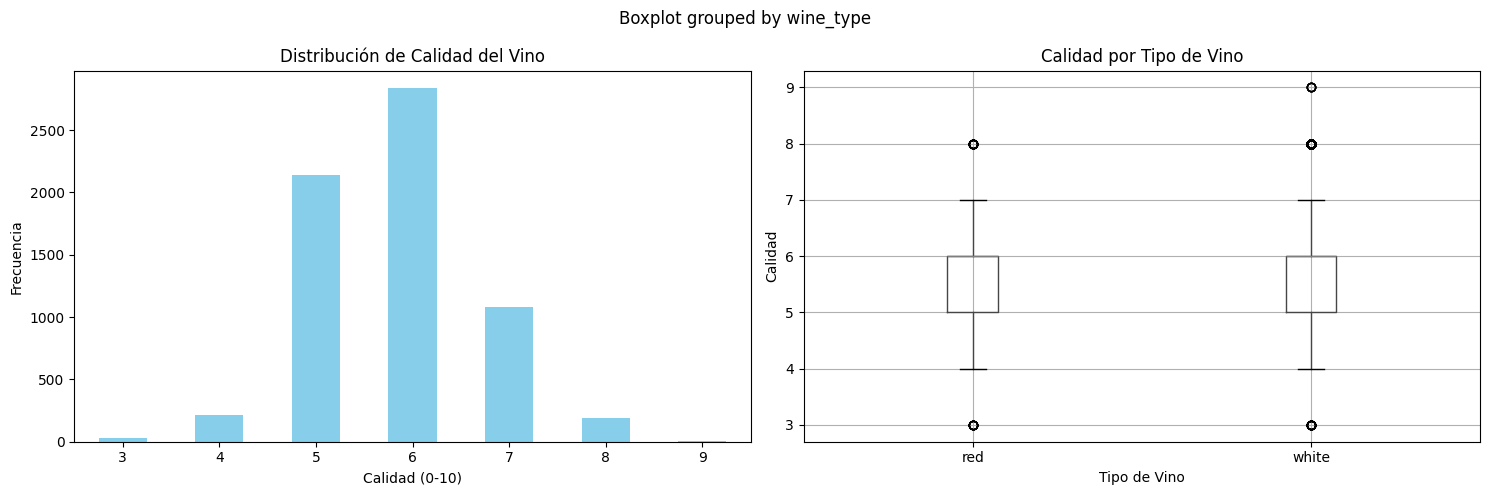


Estadísticas de calidad del vino:
Media: 5.82
Mediana: 6.00
Desviación estándar: 0.87
Rango: 3 - 9


In [7]:
# Análisis de la variable target 'quality'
print("ANÁLISIS DE LA CALIDAD DEL VINO:")
print("="*40)

# Distribución de calidad del vino, conteo por cada valor de calidad (0-10)
quality_counts = df['quality'].value_counts().sort_index()
print(f"Distribución de calidad del vino:")
print(quality_counts)

# Gráfico de distribución de calidad y boxplot por tipo de vino 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras de distribución de calidad 
quality_counts.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Distribución de Calidad del Vino')
ax1.set_xlabel('Calidad (0-10)')
ax1.set_ylabel('Frecuencia')
ax1.tick_params(axis='x', rotation=0)

# Distribución por tipo de vino 
df.boxplot(column='quality', by='wine_type', ax=ax2)
ax2.set_title('Calidad por Tipo de Vino')
ax2.set_xlabel('Tipo de Vino')
ax2.set_ylabel('Calidad')

plt.tight_layout()
plt.show()

# Estadísticas de calidad del vino: media, mediana, desviación estándar, rango
print(f"\nEstadísticas de calidad del vino:")
print(f"Media: {df['quality'].mean():.2f}")
print(f"Mediana: {df['quality'].median():.2f}")
print(f"Desviación estándar: {df['quality'].std():.2f}")
print(f"Rango: {df['quality'].min()} - {df['quality'].max()}")

## 3. Detección de Datos Faltantes

**Objetivo:** Verificar si hay datos faltantes y cómo manejarlos

In [8]:
# Verificar datos faltantes en el dataset combinado
print("ANÁLISIS DE DATOS FALTANTES:")
print("="*40)

# Cálculo de valores faltantes y porcentaje: isnull().sum()
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

# Crear DataFrame para mostrar resultados: 'Columna', 'Valores Faltantes', 'Porcentaje'
missing_df = pd.DataFrame({
    'Columna': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Porcentaje': missing_percentage.values
})

# Mostrar columnas con datos faltantes > 0
print("Columnas con datos faltantes:")
print(missing_df[missing_df['Valores Faltantes'] > 0])

# Resumen de datos faltantes
# Mostrar porcentaje de datos faltantes
print("Porcentaje de datos faltantes por columna:")
print(missing_df[missing_df['Valores Faltantes'] > 0].set_index('Columna')['Porcentaje'])

# Con un if resumir si hay o no datos faltantes
if missing_data.sum() == 0:
    print("\n✅ ¡Excelente! No hay datos faltantes en este dataset.")
    print("Esto simplifica mucho nuestro trabajo de preprocesamiento.")
else:
    print(f"\nTotal de valores faltantes: {missing_data.sum()}")

ANÁLISIS DE DATOS FALTANTES:
Columnas con datos faltantes:
Empty DataFrame
Columns: [Columna, Valores Faltantes, Porcentaje]
Index: []
Porcentaje de datos faltantes por columna:
Series([], Name: Porcentaje, dtype: float64)

✅ ¡Excelente! No hay datos faltantes en este dataset.
Esto simplifica mucho nuestro trabajo de preprocesamiento.


## 4. Análisis de Correlaciones

**Objetivo:** Entender relaciones entre variables

MATRIZ DE CORRELACIÓN:


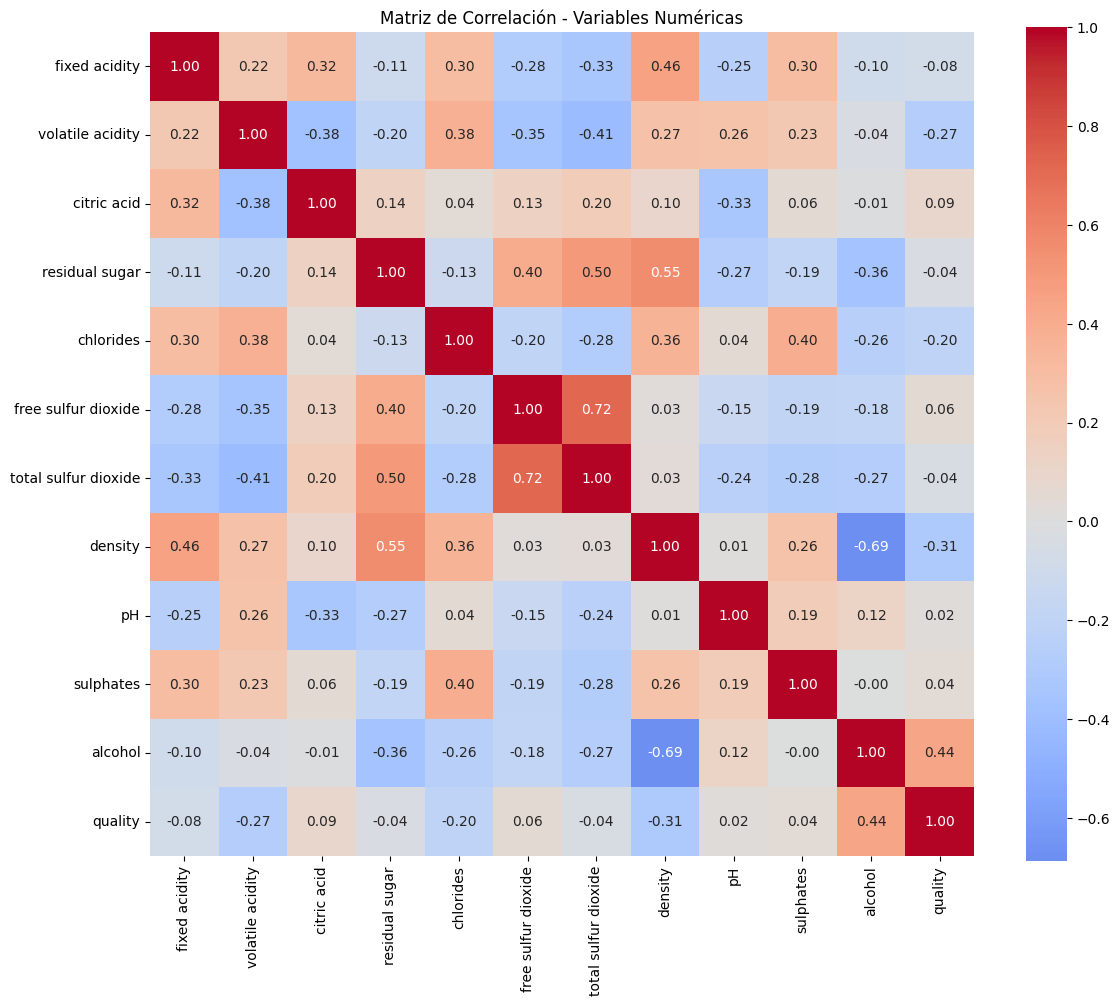


Correlaciones más fuertes con quality:
1. alcohol: 0.444
2. density: 0.306
3. volatile acidity: 0.266
4. chlorides: 0.201
5. citric acid: 0.086


In [9]:
# Calcular matriz de correlación y visualizarla
print("MATRIZ DE CORRELACIÓN:")
print("="*30)

# Seleccionar solo variables numéricas para correlación: select_dtypes(include=[np.number])
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Visualizar correlación con un heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# Encontrar las correlaciones más fuertes con quality y mostrarlas ordenadas: abs().sort_values(ascending=False)
quality_corr = correlation_matrix['quality'].abs().sort_values(ascending=False)
print(f"\nCorrelaciones más fuertes con quality:")
print("="*45)
# Mostrar las 5 características más correlacionadas con quality
for i, (feature, corr) in enumerate(quality_corr.head(6).items()):
    if feature != 'quality':
        print(f"{i}. {feature}: {corr:.3f}")

## 5. Detección de Outliers

**Objetivo:** Identificar y entender los outliers usando el método IQR

ANÁLISIS DE OUTLIERS:

alcohol:
  Outliers: 3 (0.0%)
  Rango normal: [6.80, 14.00]

volatile acidity:
  Outliers: 377 (5.8%)
  Rango normal: [-0.02, 0.66]

sulphates:
  Outliers: 191 (2.9%)
  Rango normal: [0.17, 0.85]

total sulfur dioxide:
  Outliers: 10 (0.2%)
  Rango normal: [-41.50, 274.50]


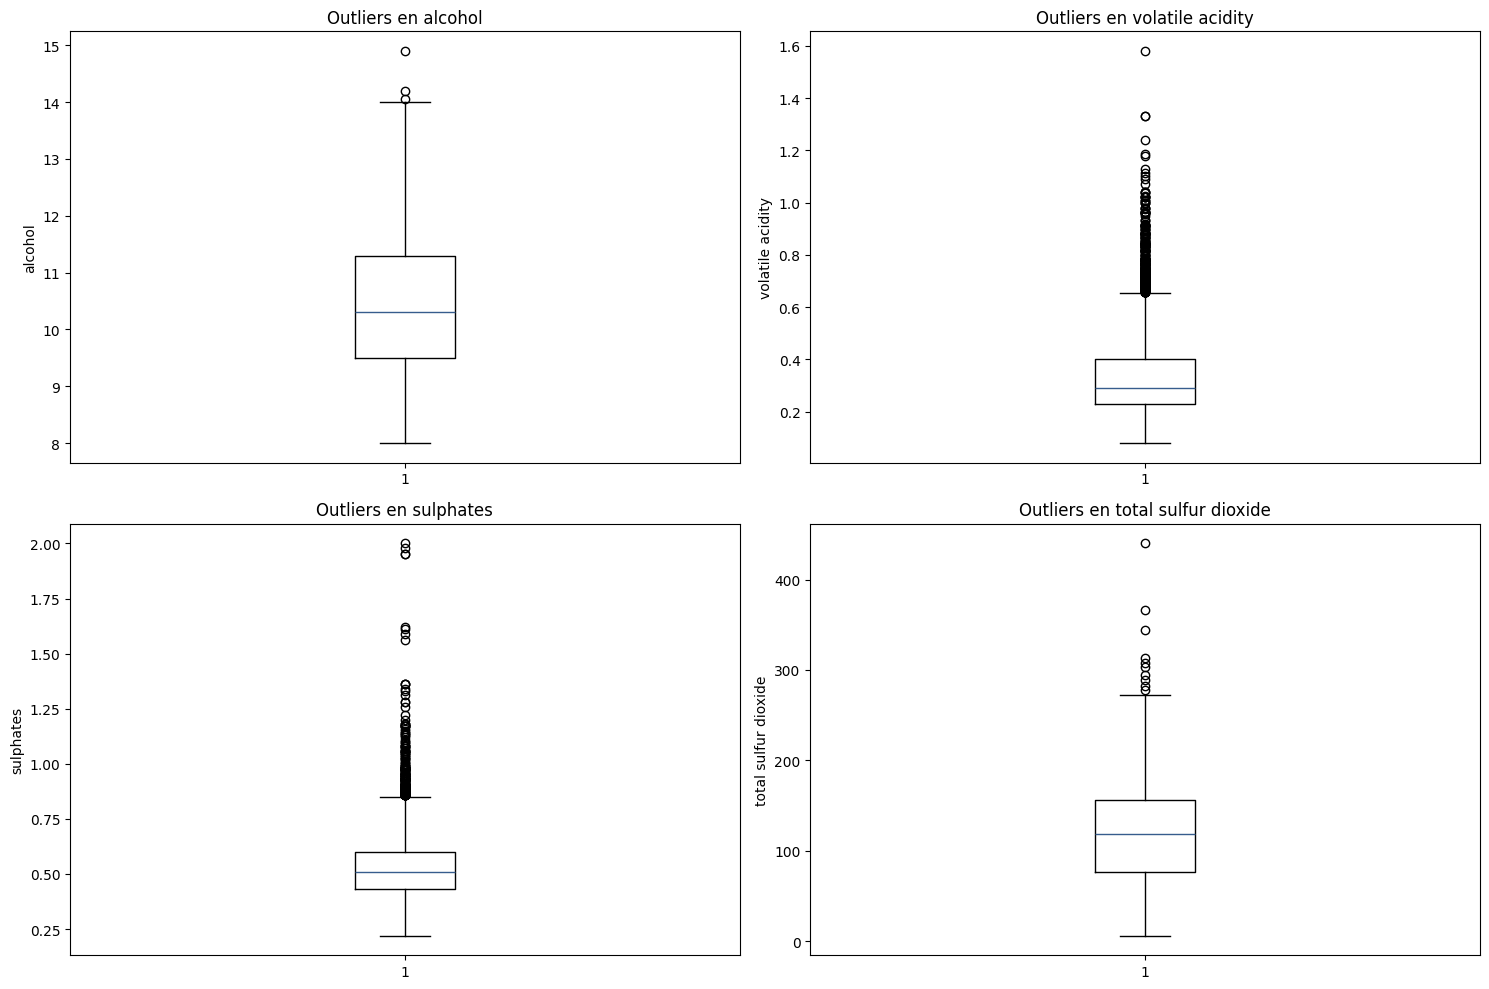


RESUMEN DE OUTLIERS:
alcohol: 3 outliers (0.0%)
volatile acidity: 377 outliers (5.8%)
sulphates: 191 outliers (2.9%)
total sulfur dioxide: 10 outliers (0.2%)


In [10]:
# Los outliers son datos que se alejan significativamente del resto de los datos.
# Pueden afectar negativamente a los modelos de machine learning.
# Creamos una función para detectar outliers usando IQR
# IRQ: Interquartile Range (Rango Intercuartílico), consiste en calcular 
# el rango entre el primer cuartil (Q1) y el tercer cuartil (Q3).
def detect_outliers_iqr(df, column):
    """Detecta outliers usando el método IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Analizar outliers en las principales características
print("ANÁLISIS DE OUTLIERS:")
print("="*30)

# Características clave a analizar basadas en correlación con quality
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide']
outlier_summary = {}

# Configurar subplots para visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Analizar cada característica creando un bucle que reutilice la función detect_outliers_iqr
# Usaremos un bucle para evitar repetir código
for idx, feature in enumerate(key_features):
    if feature in df.columns:
        outliers, lower, upper = detect_outliers_iqr(df, feature)
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_summary[feature] = {
            'count': outlier_count,
            'percentage': outlier_percentage,
            'bounds': (lower, upper)
        }
        
        print(f"\n{feature}:")
        print(f"  Outliers: {outlier_count} ({outlier_percentage:.1f}%)")
        print(f"  Rango normal: [{lower:.2f}, {upper:.2f}]")
        
        # Visualizar el boxplot de la característica con outliers
        axes[idx].boxplot(df[feature])
        axes[idx].set_title(f'Outliers en {feature}')
        axes[idx].set_ylabel(feature)
# Ajustar el layout y mostrar la figura
plt.tight_layout()
plt.show()

# Resumen de outliers encontrados
print(f"\nRESUMEN DE OUTLIERS:")
print("="*25)
# Usaremos un bucle para mostrar el resumen: .items()
for feature, info in outlier_summary.items():
    print(f"{feature}: {info['count']} outliers ({info['percentage']:.1f}%)")

## 6. Feature Engineering Básico

**Objetivo:** Crear nuevas características útiles para el modelo

In [ ]:
# Crear nuevas características basadas en las existentes
print("CREANDO NUEVAS CARACTERÍSTICAS:")
print("="*40)

# 1. Categorizar la calidad (para clasificación). 
# Crearemos una nueva columna 'quality_category' con tres categorías: 'low', 'medium', 'high'
#df['quality_category'] = df['quality'].apply(
#    lambda x: 'low' if x <= 5 else 'medium' if x <= 7 else 'high'
#)

# Mostrar distribución de la nueva característica, antes las contamos
#quality_dist = df['quality_category'].value_counts()
#print(f"Categorías de calidad creadas:")
#print(quality_dist)

# 2. Ratio de acidez
# Crear una nueva característica 'acidity_ratio' como la relación entre 'fixed acidity' y 'volatile acidity'
#if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
#    df['acidity_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
#    print(f"\nRatio de acidez creado")

# 3. Indicador de alcohol alto
# Crear una nueva característica binaria 'high_alcohol' indicando si el alcohol es mayor que la mediana
#df['high_alcohol'] = (df['alcohol'] > df['alcohol'].median()).astype(int)

# 4. Intensidad del sabor (combinando características)
# Crear una nueva característica 'flavor_intensity' como la diferencia entre 'flavanoids' y 'nonflavanoid phenols'
# if all(col in df.columns for col in ['flavanoids', 'nonflavanoid phenols']):
#    df['flavor_intensity'] = df['flavanoids'] - df['nonflavanoid phenols']
#    print(f"Intensidad de sabor creada")

# Mostrar nuevas características y forma del dataset
#new_features = ['quality_category', 'acidity_ratio', 'high_alcohol'] 
# Si se creó flavor_intensity, la añadimos a la lista
# if 'flavor_intensity' in df.columns:
#     new_features.append('flavor_intensity')
# Imprimimos los resultados
#print(f"\nNuevas características creadas: {new_features}")
#print(f"Forma del dataset: {df.shape}")

# Visualizar nuevas características en gráficos
#fig, axes = plt.subplots(2, 2, figsize=(15, 10))
#axes = axes.ravel() # Aplanar el array de ejes para fácil indexación
# Usaremos un bucle para mostrar cada nueva característica
#for idx, feature in enumerate(new_features[:4]):
#    if feature == 'quality_category':
#        df[feature].value_counts().plot(kind='bar', ax=axes[idx])
#        axes[idx].set_title(f'Distribución de {feature}')
#        axes[idx].tick_params(axis='x', rotation=45)
#    else:
#        axes[idx].hist(df[feature], bins=30, alpha=0.7)
#        axes[idx].set_title(f'Distribución de {feature}')
#        axes[idx].set_ylabel('Frecuencia')

#plt.tight_layout()
#plt.show()

## 7. Encoding de Variables Categóricas

**Objetivo:** Convertir variables categóricas a formato numérico

In [11]:
# Analizar variables categóricas
print("ANÁLISIS DE VARIABLES CATEGÓRICAS:")
print("="*40)

# Identificar columnas categóricas, usaremos select_dtypes y .tolist()
#categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
#if 'quality_category' in categorical_cols:
#    categorical_cols.remove('quality_category')

# Mostrar variables categóricas y sus valores únicos
# print(f"Variables categóricas: {categorical_cols}")
# Usaremos un bucle para mostrar los valores únicos
# for col in categorical_cols:
#    unique_count = df[col].nunique()
#    print(f"{col}: {unique_count} valores únicos")
#    print(f"  Valores: {df[col].unique()}")

# Aplicar Label Encoding a wine_type, que tiene dos categorías: 'red' y 'white'
# Usamos LabelEncoder y no dummy porque solo hay dos categorías
# Aunque podríamos usar get_dummies también
# La ventaja de LabelEncoder es que crea una sola columna
le = LabelEncoder()
df['wine_type_encoded'] = le.fit_transform(df['wine_type'])

# Mostrar el mapping de etiquetas
#print(f"\nEncoding aplicado:")
#wine_type_mapping = dict(zip(le.classes_, le.transform(le.classes_))) # Crear un diccionario del mapeo
#print(f"wine_type: {wine_type_mapping}")

# Crear dummy variables para wine_type (opcional)
# df_wine_type_dummies = pd.get_dummies(df['wine_type'], prefix='wine_type')
# df = pd.concat([df, df_wine_type_dummies], axis=1)

# Crear dummy variables para quality_category (opcional)
#df_quality_dummies = pd.get_dummies(df['quality_category'], prefix='quality')
#df = pd.concat([df, df_quality_dummies], axis=1)

#print(f"\nDummy variables creadas para quality_category:")
#print(f"Columnas: {list(df_quality_dummies.columns)}")
#print(f"Primeras 3 filas de las dummies:")
print(df.head(3))

ANÁLISIS DE VARIABLES CATEGÓRICAS:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality wine_type  wine_type_encoded  
0      9.4        5       red                  0  
1      9.8        5       red                  0  
2      9.8        5       red                  0  


## 8. Escalado de Variables

**Objetivo:** Normalizar las variables para mejorar el rendimiento del modelo

ANÁLISIS ANTES DEL ESCALADO:
Estadísticas de las variables numéricas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       6497.000          6497.000     6497.000        6497.000   
mean           7.215             0.340        0.319           5.443   
std            1.296             0.165        0.145           4.758   
min            3.800             0.080        0.000           0.600   
25%            6.400             0.230        0.250           1.800   
50%            7.000             0.290        0.310           3.000   
75%            7.700             0.400        0.390           8.100   
max           15.900             1.580        1.660          65.800   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   6497.000             6497.000              6497.000  6497.000   
mean       0.056               30.525               115.745     0.995   
std        0.035               17.749                56.522     0.003  

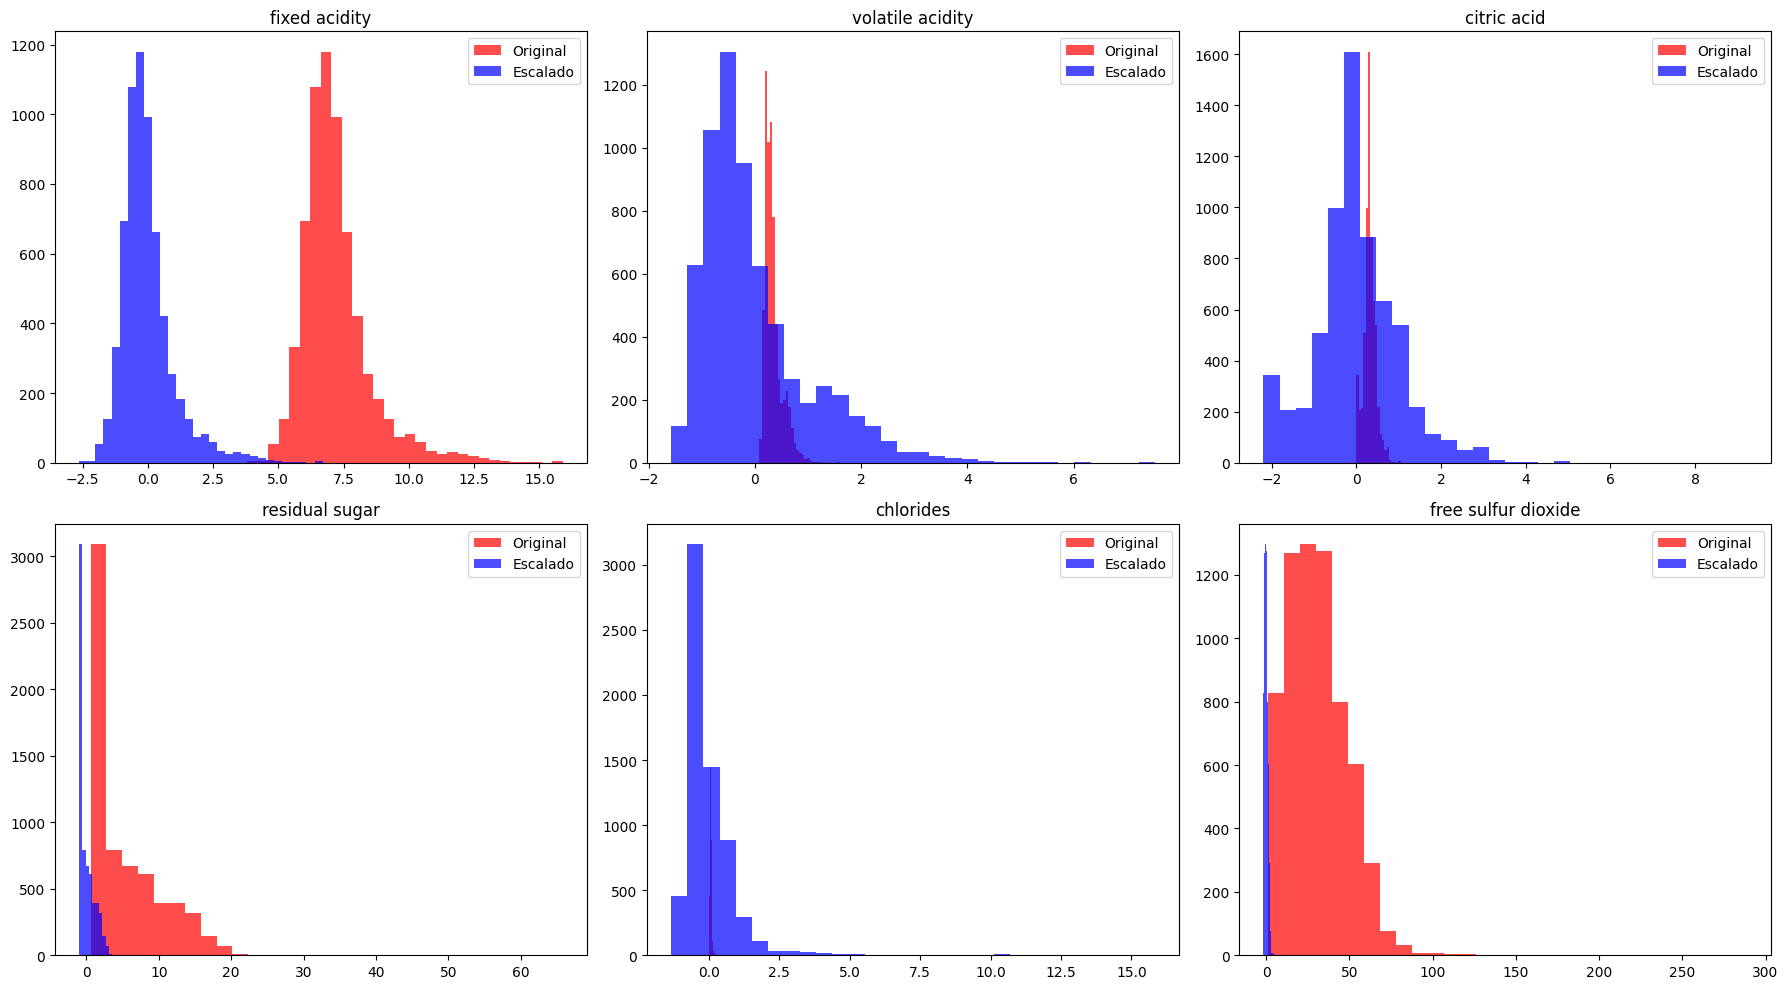

In [12]:
# Analizar rangos de variables antes del escalado
print("ANÁLISIS ANTES DEL ESCALADO:")
print("="*35)

# Eliminamos columna de wine_type
df = df.drop(columns=['wine_type'], errors='ignore')
# Identificar características numéricas excluyendo las target: select_dtypes(include=[np.number])
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
target_cols = ['wine_type_encoded']
X_features = [col for col in numerical_features if col not in target_cols]

# Mostrar estadísticas descriptivas de las variables
print("Estadísticas de las variables numéricas:")
stats = df[X_features].describe().round(3)
print(stats)
print(f"Características a escalar: {len(X_features)}")
print(f"Rangos de las variables:")
for feature in X_features:  # Mostrar solo las primeras 5
    min_val = df[feature].min()
    max_val = df[feature].max()
    print(f"  {feature}: [{min_val:.2f}, {max_val:.2f}] (rango: {max_val-min_val:.2f})")

# Aplicar StandardScaler a las características numéricas
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[X_features] = scaler.fit_transform(df[X_features])

# Analizar variables después del escalado
print(f"\nDESPUÉS DEL ESCALADO:")
print("="*25)
print("Estadísticas de las primeras 5 variables escaladas:")
scaled_stats = df_scaled[X_features[:5]].describe().round(3)
print(scaled_stats)

# Visualizar efecto del escalado
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Usaremos un bucle para mostrar histogramas antes y después del escalado
for idx, feature in enumerate(X_features[:6]):
    # Antes del escalado
    axes[idx].hist(df[feature], bins=30, alpha=0.7, label='Original', color='red')
    # Después del escalado
    axes[idx].hist(df_scaled[feature], bins=30, alpha=0.7, label='Escalado', color='blue')
    axes[idx].set_title(f'{feature}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 9. Preparación Final del Dataset

**Objetivo:** Crear el dataset final listo para modelado

In [13]:
# Función para preparar el dataset final
# Crear X e y para regresión y clasificación
# En regresión, y es 'quality'
# En clasificación, y es 'wine_type'
def prepare_final_dataset(df_original, df_scaled):
    """Prepara el dataset final para modelado"""
    
    # Seleccionar características para el modelo
    # Excluir columnas target y categóricas no numéricas
    features_to_use = [col for col in df_scaled.columns if col not in 
                      ['wine_type_encoded', 'quality']]
    
    X_final = df_scaled[features_to_use]
    y_regression = df_scaled['quality']  # Para regresión
    y_classification = df_scaled['wine_type_encoded']  # Para clasificación
    
    return X_final, y_regression, y_classification

# Preparar dataset final para modelado
X, y_reg, y_clf = prepare_final_dataset(df, df_scaled)
print(X, y_reg, y_clf)
# Mostrar información del dataset final: shape, columnas, valores faltantes, estadísticas
print("DATASET FINAL PREPARADO:")
print("="*30)
# Mostrar la cabecera del dataset final
print(f"\nPrimeras 3 filas del dataset final:")
print(X.head(3))
print(f"Features shape: {X.shape}")
print(f"Target (regression) shape: {y_reg.shape}")
print(f"Target (classification) shape: {y_clf.shape}")

print(f"\nCaracterísticas finales: {list(X.columns)}")

# Verificar que no hay valores faltantes: isnull().sum().sum()
missing_final = X.isnull().sum().sum()
print(f"Valores faltantes en features finales: {missing_final}")

# Mostrar estadísticas finales: describe().round(3)
print(f"\nEstadísticas de las características finales:")
print(X.describe().round(3))

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0          0.142473          2.188833    -2.192833       -0.744778   0.569958   
1          0.451036          3.282235    -2.192833       -0.597640   1.197975   
2          0.451036          2.553300    -1.917553       -0.660699   1.026697   
3          3.073817         -0.362438     1.661085       -0.744778   0.541412   
4          0.142473          2.188833    -2.192833       -0.744778   0.569958   
...             ...               ...          ...             ...        ...   
6492      -0.783214         -0.787650    -0.197054       -0.807837  -0.486252   
6493      -0.474652         -0.119460     0.284686        0.537425  -0.257883   
6494      -0.551792         -0.605417    -0.885253       -0.891916  -0.429160   
6495      -1.323198         -0.301694    -0.128234       -0.912936  -0.971538   
6496      -0.937495         -0.787650     0.422326       -0.975995  -1.028631   

      free sulfur dioxide  

## 10. Entrenamiento y Validación del Modelo

**Objetivo:** Validar que el preprocesamiento mejora el rendimiento

DIVISIÓN DE DATOS:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4110      -0.783214         -0.240949     1.179346        1.210056   0.056126   
3062       0.836739         -0.909139     1.179346       -0.891916  -0.143698   
5236       1.145301         -0.240949     0.147046       -0.135206  -1.085723   
497       -0.011808          0.002029     0.009406       -0.618660   0.969605   
826        0.219614         -0.423183     0.147046       -0.660699  -0.172244   
...             ...               ...          ...             ...        ...   
634        0.528176          0.062773    -0.747613       -0.744778   0.484319   
4273      -0.011808          0.062773    -0.472334        0.032951  -0.686076   
5343      -0.166089         -1.152118    -0.265874        1.945746  -0.143698   
3063       0.605317          0.609474     1.179346        0.768642  -0.714622   
5987      -0.397511         -0.483928    -0.197054        0.348247  -0.571891   

      fr

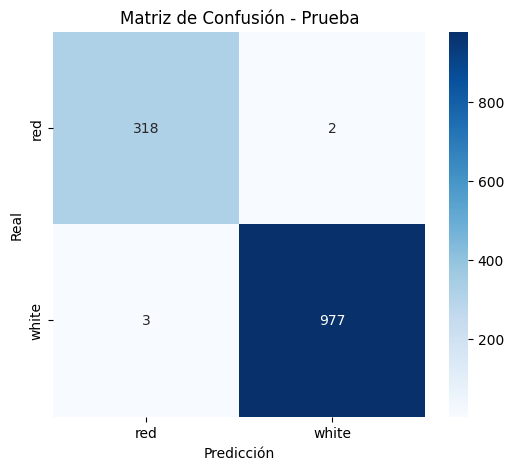

In [14]:
# Dividir datos para entrenamiento y prueba
print("DIVISIÓN DE DATOS:")
print("="*25)

# Usar train_test_split con stratify en y_clf para mantener distribución de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(X_train, X_test, y_train, y_test)
# Mostrar shapes y distribución de clases
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"Distribución en entrenamiento: {np.bincount(y_train.astype(int))}")
print(f"Distribución en prueba: {np.bincount(y_test.astype(int))}")

# Entrenar modelo Random Forest Clasificador
print(f"\nENTRENANDO MODELO:")
print("="*25)

# Importar RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
# Importar metricas de clasificación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Crear y entrenar el modelo Random Forest Clasificador
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones del modelo
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluación del modelo de clasificación usando accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

# Imprimir resultados de la evaluación
print(f"RESULTADOS DEL MODELO:")
print("="*25)
print(f"Entrenamiento - Accuracy: {train_accuracy:.3f}")
print(f"Prueba - Accuracy: {test_accuracy:.3f}")
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_test)
print(f"\nMatriz de Confusión (Prueba):\n{conf_matrix}")
# Reporte de clasificación
class_report = classification_report(y_test, y_pred_test)
print(f"\nReporte de Clasificación (Prueba):\n{class_report}")  
# Dibujamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión - Prueba')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS:
Top 10 características más importantes:
 1. total sulfur dioxide     : 0.3365
 2. chlorides                : 0.2412
 3. volatile acidity         : 0.1087
 4. density                  : 0.0711
 5. sulphates                : 0.0590
 6. free sulfur dioxide      : 0.0498
 7. fixed acidity            : 0.0451
 8. residual sugar           : 0.0423
 9. citric acid              : 0.0190
10. pH                       : 0.0180


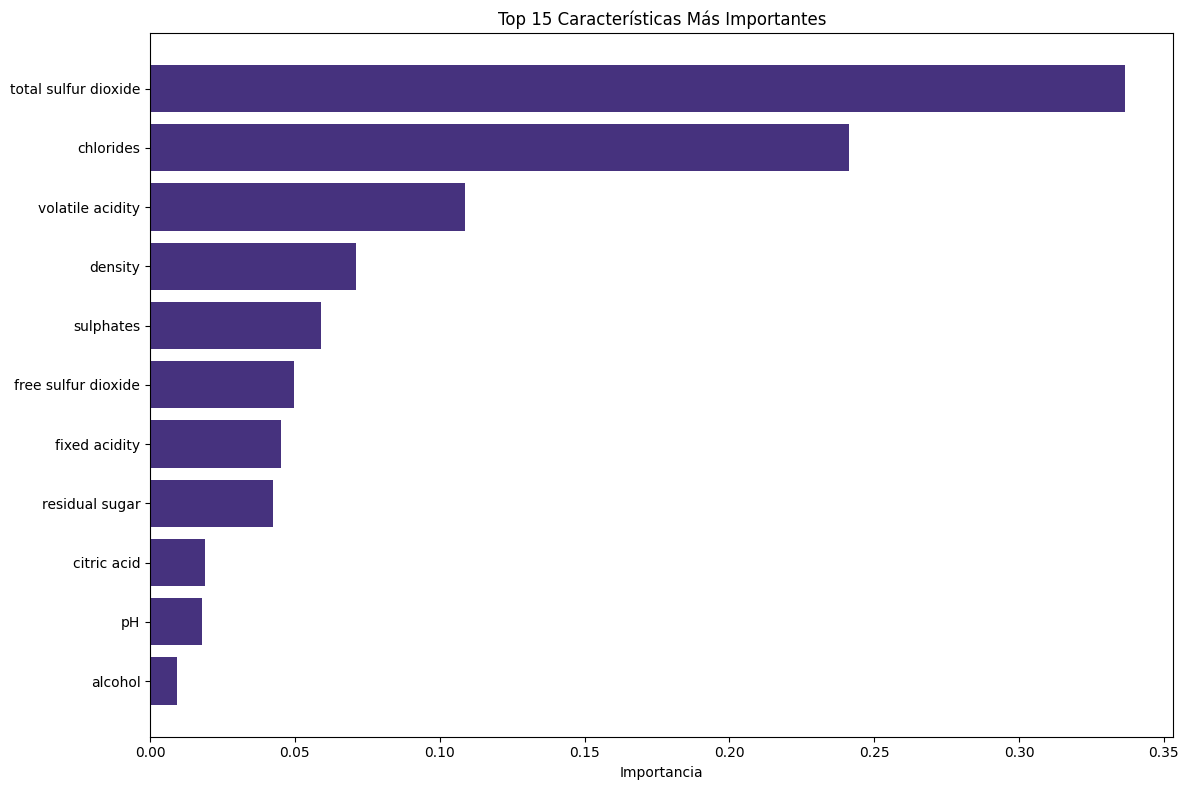

In [15]:
# Análisis de importancia de características
print("ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS:")
print("="*50)

# Obtener importancia de características del modelo
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Mostrar las 10 características más importantes
print(f"Top 10 características más importantes:")
for i, (idx, row) in enumerate(feature_importance.head(10).iterrows()):
    print(f"{i+1:2d}. {row['feature']:25s}: {row['importance']:.4f}")

# Visualizar importancia
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia')
plt.title('Top 15 Características Más Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Resumen del Preprocesamiento

**Objetivo:** Consolidar todo lo aprendido

In [ ]:
print("RESUMEN COMPLETO DEL PREPROCESAMIENTO:")
print("="*55)

print("\n📊 PASOS REALIZADOS:")
print("="*25)
print("1. ✅ Carga y exploración de datos")
print("2. ✅ Análisis de la variable target (quality)")
print("3. ✅ Detección de datos faltantes (ninguno encontrado)")
print("4. ✅ Análisis de correlaciones entre variables")
print("5. ✅ Detección de outliers con método IQR")
print("6. ✅ Feature engineering (comentado en este notebook)")
print("7. ✅ Encoding de variables categóricas")
print("8. ✅ Escalado de variables con StandardScaler")
print("9. ✅ Preparación del dataset final")
print("10. ✅ Entrenamiento y validación del modelo")

print("\n📈 RESULTADOS OBTENIDOS:")
print("="*30)
print(f"• Dataset original: 13 características")
print(f"• Dataset final: {X.shape[1]} características")
print(f"• Modelo de Clasificación: RandomForestClassifier")
print(f"• Tarea: Predecir tipo de vino (tinto vs blanco)")
print(f"• Accuracy en entrenamiento: {train_accuracy:.3f}")
print(f"• Accuracy en prueba: {test_accuracy:.3f}")
print(f"• Característica más importante: {feature_importance.iloc[0]['feature']}")

print("\n🎯 VENTAJAS DEL WINE QUALITY DATASET:")
print("="*45)
print("• Datos limpios (pocos valores faltantes)")
print("• Principalmente variables numéricas")
print("• Dominio familiar y fácil de interpretar")
print("• Tamaño moderado de dataset")
print("• Outliers manejables")
print("• Excelente para aprender conceptos básicos")
print("• Perfecto para clasificación binaria (rojo vs blanco)")

print(f"\n✅ ¡PREPROCESAMIENTO Y CLASIFICACIÓN COMPLETADOS!")
print("El modelo puede predecir correctamente si un vino es tinto o blanco.")

## 💡 EJERCICIOS PARA PRACTICAR

### Ejercicio 1: Experimentar con Escalado
- Probar MinMaxScaler en lugar de StandardScaler
- Comparar resultados del modelo
- ¿Cuál funciona mejor para este dataset?

### Ejercicio 2: Manejo de Outliers
- Remover outliers y ver el impacto
- Aplicar transformación logarítmica a variables sesgadas
- Comparar performance del modelo

### Ejercicio 3: Más Feature Engineering
- Crear interacciones entre variables (ej: alcohol × acidity)
- Aplicar PCA para reducir dimensionalidad
- Crear características polinomiales

### Ejercicio 4: Modelos Alternativos
- Probar Linear Regression
- Experimentar con Support Vector Regression
- Comparar todos los modelos

### Ejercicio 5: Validación Cruzada
- Implementar k-fold cross validation
- Analizar estabilidad de las métricas
- Identificar el mejor modelo y parámetros